## picograd demo

In [25]:
from picograd.engine import Value
from picograd.nn import Neuron, Layer, MLP

import random
import numpy as np
import matplotlib.pyplot as plt

(1000, 2) (1000,)


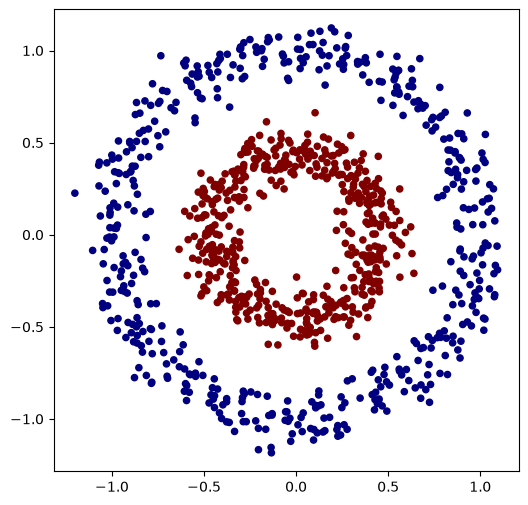

In [26]:
from sklearn.datasets import make_circles

X, y = make_circles(
    n_samples=1000,
    noise=0.08,
    factor=0.45,
    random_state=42
)

print(X.shape, y.shape)

plt.figure(figsize=(6, 6))
plt.scatter(
    X[:, 0],
    X[:, 1],
    c=y,
    s=20,
    cmap="jet"
)
plt.axis("equal")
plt.show()

In [27]:
print(y[:10])

[1 1 1 1 0 1 1 1 1 0]


In [28]:
model = MLP(2, [24, 24, 1])
print(model)
print("number of parameters", len(model.parameters()))


MLP of [Layer of [ReLU Neuron(2), ReLU Neuron(2), ReLU Neuron(2), ReLU Neuron(2), ReLU Neuron(2), ReLU Neuron(2), ReLU Neuron(2), ReLU Neuron(2), ReLU Neuron(2), ReLU Neuron(2), ReLU Neuron(2), ReLU Neuron(2), ReLU Neuron(2), ReLU Neuron(2), ReLU Neuron(2), ReLU Neuron(2), ReLU Neuron(2), ReLU Neuron(2), ReLU Neuron(2), ReLU Neuron(2), ReLU Neuron(2), ReLU Neuron(2), ReLU Neuron(2), ReLU Neuron(2)], Layer of [ReLU Neuron(24), ReLU Neuron(24), ReLU Neuron(24), ReLU Neuron(24), ReLU Neuron(24), ReLU Neuron(24), ReLU Neuron(24), ReLU Neuron(24), ReLU Neuron(24), ReLU Neuron(24), ReLU Neuron(24), ReLU Neuron(24), ReLU Neuron(24), ReLU Neuron(24), ReLU Neuron(24), ReLU Neuron(24), ReLU Neuron(24), ReLU Neuron(24), ReLU Neuron(24), ReLU Neuron(24), ReLU Neuron(24), ReLU Neuron(24), ReLU Neuron(24), ReLU Neuron(24)], Layer of [LinearNeuron(24)]]
number of parameters 697


In [ ]:
def loss_function(batch_size = None):
    #dataloader
    if batch_size==None:
        Xb, yb = X, y
    else:
        ri = np.random.permutation(X.shape[0])[:batch_size]
        Xb, yb = X[ri], y[ri]

    inputs = [list(map(Value, Xrow)) for Xrow in Xb]

    scores = list(map(model, inputs))

    probs = [score.sigmoid() for score in scores]

    # Binary Cross Entropy loss
    losses = [Value(-1) * (Value(yi) * pi.log() + Value(1 - yi) * (Value(-1) * pi + Value(1)).log())for yi, pi in zip(yb, probs)]

    data_loss = Value(0)
    for loss in losses:
        data_loss = data_loss + loss

    data_loss = data_loss * Value(1 / len(losses))

    # L2 regularization
    alpha = 1e-4
    reg_loss = alpha * sum((p * p for p in model.parameters()))

    total_loss = data_loss + reg_loss

    # Accuracy
    accuracy = [yi == (pi.data > 0.5) for yi, pi in zip(yb, probs)]

    return total_loss, sum(accuracy) / len(accuracy)

In [30]:
for i in range(10):

    #forward
    total_loss, acc = loss_function()

    #backward
    model.zero_grad()
    loss_function.backward()

    #update weights
    learning_rate = 1.0 - 0.9*i/100
    for p in model.parameters():
        p.data -= learning_rate * p.grad
    
    if i % 1 == 0:
        print(f"step {i} loss {total_loss.data}, accuracy {acc*100}%")
    

TypeError: unsupported operand type(s) for +: 'int' and 'Value'